# Diabetic Retinopathy Screening Agent
**Vicheda Narith, Maanvi Sarwadi**

*CS496: Agentic AI*

End-to-end pipeline:
1. **Vision Agent**: EfficientNet-B0 screens retinal images, grades DR 0–4, quantifies uncertainty via MC Dropout
2. **Retrieval Agent**: FAISS semantic search over clinical guidelines, LangChain enforces clinical protocols
3. **Agentic Logic Layer**: MDP policy routes to DIAGNOSE or REFER based on entropy threshold

## Setup & Dependencies

Run the following script to load packages and dependencies

In [187]:
!pip install -q faiss-cpu sentence-transformers

In [188]:
import os
import re
import xml.etree.ElementTree as ET
import faiss
import numpy as np
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer
from torchvision import transforms

In [189]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = "/content/dr_best.pth" # for colab session
# CHECKPOINT_PATH = f"/content/drive/MyDrive/3rd Year: 2025-2026/Spring Quarter/CS 496: Agent AI/final_project/checkpoints/dr_best.pth"
# os_checkpoint_path = "checkpoints/dr_best.pth"

# hyperparameters
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-4
UNCERTAINTY_THRESHOLD = 0.5 # Entropy decision policy cutoff
MC_PASSES = 30 # Forward stochastic sweeps for dropout active

DR_GRADES = {
    0: "No apparent DR",
    1: "Mild NPDR",
    2: "Moderate NPDR",
    3: "Severe NPDR",
    4: "Proliferative DR",
}

In [190]:
# # from google.colab import drive
# # drive.mount('/content/drive')

# verify checkpoint path
if os.path.exists(CHECKPOINT_PATH):
    print(f"True {CHECKPOINT_PATH}")
else:
    print(f"Error: Cannot find checkpoint at {CHECKPOINT_PATH}")

True /content/dr_best.pth


## Load APTOS data

In [191]:
# transforms to apply images
def get_transforms():
    return transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ]
    )

In [192]:
# Load APTOS with labels — already 224x224, no preprocessing needed
aptos = load_dataset("bumbledeep/aptos", split="train")

print(aptos)
print(aptos.features)
print(aptos[0].keys())  # should show: image, label_code, label

Dataset({
    features: ['image', 'label_code', 'label'],
    num_rows: 3662
})
{'image': Image(mode=None, decode=True), 'label_code': Value('int64'), 'label': Value('string')}
dict_keys(['image', 'label_code', 'label'])


In [193]:
class DRDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data      = data
        self.transform = transform or get_transforms()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data[idx]
        img   = row['image'].convert('RGB')
        label = row['label_code']  # integer 0–4
        if self.transform:
            img = self.transform(img)
        return img, label

# Train/val split (85/15)
n = len(aptos)
n_train = int(0.85 * n)
n_val = n - n_train

train_data, val_data = random_split(aptos, [n_train, n_val],
                                     generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(DRDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(DRDataset(val_data),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train: {n_train} | Val: {n_val}')

Train: 3112 | Val: 550


In [194]:
class DRVisionModel(nn.Module):
    def __init__(self, num_classes=5, dropout_rate=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            num_classes=0
        )
        feature_dim = self.backbone.num_features  # 1536

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))

    def enable_mc_dropout(self):
        for m in self.modules():
            if isinstance(m, nn.Dropout):
                m.train()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = DRVisionModel().to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()
print('Weights loaded.')

print(f'Device: {DEVICE}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Weights loaded.
Device: cuda
Parameters: 4,665,985


In [195]:
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
# clear memory
torch.cuda.empty_cache()

In [196]:
from collections import Counter
labels = [aptos[i]['label_code'] for i in range(len(aptos))]
dist = Counter(labels)
print(dist)

Counter({0: 1805, 2: 999, 1: 370, 4: 295, 3: 193})


In [197]:
def plot_training_history(train_losses, val_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, 'o-', color='steelblue', label='Train Loss')
    plt.plot(val_losses,   'o-', color='coral',     label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [198]:
from tqdm import tqdm

def train(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, patience=3,
    min_delta=1e-4):
    """
    Fine-tunes the Vision Agent backbone (EfficientNet-B0) on the dataset.
    Tracks historical loss curves across epochs to support model convergence plots.
    """
    # class weights penalize misclassifying rare severe grades more harshly
    class_weights = torch.tensor([0.5, 1.5, 2.0, 2.5, 3.0]).to(DEVICE)

    criterion     = nn.CrossEntropyLoss(weight=class_weights)
    optimizer     = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler     = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    os.makedirs('/content/checkpoints', exist_ok=True)
    best_val_loss = float('inf')

    # early stopping
    patience_counter = 0
    early_stop = False

    # arrays to capture progression metrics over runtime milestones
    history_train_losses = []
    history_val_losses   = []

    print(f"Starting training backbone optimization loop on device: {DEVICE}")

    for epoch in range(epochs):
        # train
        model.train()
        running_train_loss = 0.0

        for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]'):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        # validate
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]'):
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                val_loss = criterion(outputs, labels)
                running_val_loss += val_loss.item()

        # calculate performance averages for this epoch milestone
        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_val_loss   = running_val_loss / len(val_loader)
        scheduler.step()

        # save historical values into tracing structures
        history_train_losses.append(epoch_train_loss)
        history_val_losses.append(epoch_val_loss)

        print(f'Epoch {epoch+1:02d} Summary -> train_loss: {epoch_train_loss:.4f} | val_loss: {epoch_val_loss:.4f}')

        # early stopping
        # check if the validation loss improved by at least min_delta
        if epoch_val_loss < (best_val_loss - min_delta):
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print(f'New optimal weights saved to {CHECKPOINT_PATH}')
            patience_counter = 0  # reset patience counter if improvement occurred
        else:
            patience_counter += 1
            print(f'No significant validation improvement. Patience: {patience_counter}/{patience}')

            if patience_counter >= patience:
                print(f'Early Stopped at epoch {epoch+1} to keep generalization.')
                early_stop = True
                break
    print('Training loop finalized.')
    return history_train_losses, history_val_losses

Starting training backbone optimization loop on device: cuda


Epoch 1/10 [Val]: 100%|██████████| 35/35 [00:01<00:00, 26.82it/s]


Epoch 01 Summary -> train_loss: 1.1535 | val_loss: 0.8870
New optimal weights saved to /content/dr_best.pth


Epoch 2/10 [Val]: 100%|██████████| 35/35 [00:01<00:00, 26.97it/s]


Epoch 02 Summary -> train_loss: 0.8316 | val_loss: 0.7748
New optimal weights saved to /content/dr_best.pth


...

Epoch 05 Summary -> train_loss: 0.4696 | val_loss: 0.7282
No significant validation improvement. Patience: 1/3


Epoch 6/10 [Val]: 100%|██████████| 35/35 [00:01<00:00, 26.83it/s]


Epoch 06 Summary -> train_loss: 0.3900 | val_loss: 0.7617
No significant validation improvement. Patience: 2/3


Epoch 7/10 [Val]: 100%|██████████| 35/35 [00:01<00:00, 26.72it/s]


Epoch 07 Summary -> train_loss: 0.3120 | val_loss: 0.7699
No significant validation improvement. Patience: 3/3
Early Stopped at epoch 7 to keep generalization.
Training loop finalized.


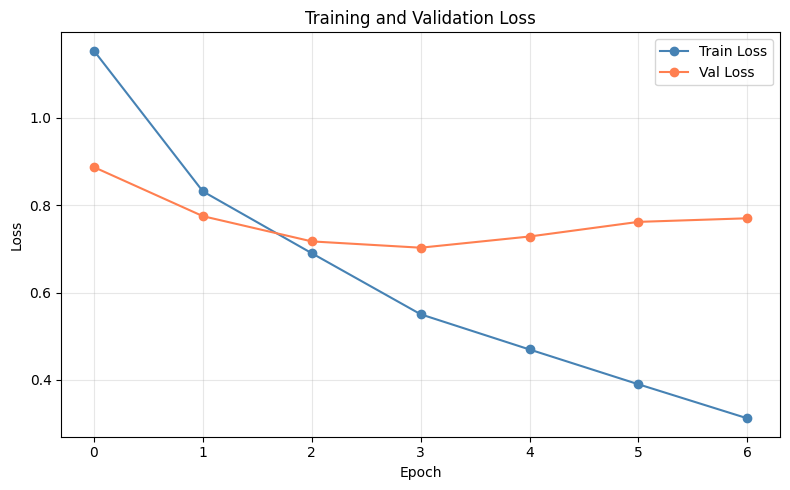

In [199]:
# clean model structure
model = DRVisionModel().to(DEVICE)

train_losses, val_losses = train(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE)

# plot historical loss tracks
plot_training_history(train_losses, val_losses)

In [200]:
# Monte Carlo Dropout
def mc_dropout_predict(model, image_tensor, n_passes=30):
    """
    Run n_passes stochastic forward passes with dropout active.
    Returns grade prediction + uncertainty scores.
    """
    model.eval()
    model.enable_mc_dropout()  # keep dropout on during inference

    image_tensor = image_tensor.to(DEVICE)
    all_probs = []

    with torch.no_grad():
        for _ in range(n_passes):
            logits = model(image_tensor)
            probs  = F.softmax(logits, dim=1)
            all_probs.append(probs.cpu().numpy())

    all_probs  = np.array(all_probs).squeeze()
    probs_mean = all_probs.mean(axis=0)
    all_preds  = np.argmax(all_probs, axis=1)

    return {
        'grade':      int(np.argmax(probs_mean)),
        'grade_label': DR_GRADES[int(np.argmax(probs_mean))],
        'confidence': float(probs_mean.max()),
        'variance':   float(np.var(all_preds)),
        'entropy':    float(-np.sum(probs_mean * np.log(probs_mean + 1e-8))),
        'probs_mean': probs_mean.tolist(),
        'all_preds':  all_preds.tolist()
    }

In [201]:
# Validate Image
import cv2

def check_image_quality(img: Image.Image) -> dict:
    """
    Checks blur and field-of-view before grading.
    Rejects images that are too blurry or poorly framed.
    """
    img_gray = np.array(img.convert('L'))

    # Blur detection via Laplacian variance
    blur_score = cv2.Laplacian(img_gray, cv2.CV_64F).var()
    if blur_score < 50:
        return {'valid': False, 'reason': f'Image too blurry (score: {blur_score:.1f})'}

    # Field of view: retinal disc should fill >15% of frame
    non_black = np.sum(img_gray > 10) / img_gray.size
    if non_black < 0.15:
        return {'valid': False, 'reason': f'Insufficient field of view ({non_black:.1%})'}

    return {'valid': True, 'reason': 'OK'}

## Retrieval Agent

### Fetch data pipeline

In [202]:
# medical queries to pool relevant data rows from live servers
DR_QUERIES = [
    "diabetic retinopathy",
    "diabetic retinopathy treatment",
    "nonproliferative diabetic retinopathy",
    "proliferative diabetic retinopathy",
    "diabetic macular edema",
]

def fetch_medlineplus_search(query):
    """Queries live NLM servers using the MedlinePlus Health Topics endpoint."""
    url = "https://wsearch.nlm.nih.gov/ws/query"
    params = {
        "db": "healthTopics",
        "term": query,
    }
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        return response.text  # Endpoint returns structured XML data
    except Exception as e:
        print(f" Live network fetch failed for query '{query}': {e}")
        return None

def parse_medlineplus_xml(xml_text, query):
    """Extracts raw title, summary, and source URL parameters from standard NLM XML schemas."""
    entries = []
    if not xml_text:
        return entries

    try:
        root = ET.fromstring(xml_text)
    except ET.ParseError:
        return entries

    for doc in root.findall(".//document"):
        title = ""
        summary = ""
        url = doc.get("url", "")

        for content in doc.findall("content"):
            name = content.get("name", "")
            if name == "title":
                title = content.text or ""
            if name == "FullSummary":
                summary = content.text or ""
            if name == "snippet" and not summary:
                summary = content.text or ""

        if summary and len(summary.strip()) > 30:
            # strip standard HTML rendering markers from summaries using regex matching
            clean_text = re.sub(r"<[^>]+>", "", summary).strip()
            entries.append(
                {
                    "id": f"nlm_{len(entries)}_{np.random.randint(100,999)}",
                    "source": f"MedlinePlus NIH — {title}",
                    "text": clean_text[:500],  # Capture descriptive diagnostic context limits
                    "url": url,
                    "query": query,
                }
            )
    return entries

In [203]:
# compile the documents
print("Connecting to National Library of Medicine API Endpoint...")
RAW_KNOWLEDGE_BASE = []

for query_term in DR_QUERIES:
    print(f"   Requesting dynamic query matching: '{query_term}'...")
    xml_payload = fetch_medlineplus_search(query_term)
    extracted_nodes = parse_medlineplus_xml(xml_payload, query_term)
    RAW_KNOWLEDGE_BASE.extend(extracted_nodes)

# deduplicate clinical passages according to their underlying NLM url
seen_urls = set()
KNOWLEDGE_BASE = [
    doc
    for doc in RAW_KNOWLEDGE_BASE
    if doc["url"] not in seen_urls and not seen_urls.add(doc["url"])
]

if not KNOWLEDGE_BASE:
    raise ValueError(
        "Database initialization failed. Verify server access or network connection bounds."
    )

print(
    f"Compiled {len(KNOWLEDGE_BASE)} NIH document paths."
)

Connecting to National Library of Medicine API Endpoint...
   Requesting dynamic query matching: 'diabetic retinopathy'...
   Requesting dynamic query matching: 'diabetic retinopathy treatment'...
   Requesting dynamic query matching: 'nonproliferative diabetic retinopathy'...
   Requesting dynamic query matching: 'proliferative diabetic retinopathy'...
   Requesting dynamic query matching: 'diabetic macular edema'...
Compiled 7 NIH document paths.


### FAISS DB Vector store

In [204]:

# build emantic FAISS DB Vector store
print("Initializing dense MiniLM semantic encoder models...")
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

texts_to_embed = [doc["text"] for doc in KNOWLEDGE_BASE]
corpus_embeddings = embedder.encode(texts_to_embed, convert_to_numpy=True)
faiss.normalize_L2(corpus_embeddings)  # L2 normalize properties for exact Cosine tracking

vector_dimension = corpus_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(vector_dimension)  # Flat inner product calculates cosine distance
faiss_index.add(corpus_embeddings)
print(
    f"FAISS vector database officially serialized with {faiss_index.ntotal} nodes."
)


def retrieve(query, top_k=2):
    """Performs continuous vector math sweeps to extract semantic guidelines matching input queries."""
    query_vector = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_vector)
    scores, indices = faiss_index.search(query_vector, top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx < len(KNOWLEDGE_BASE):
            hit = KNOWLEDGE_BASE[idx].copy()
            hit["score"] = float(score)
            results.append(hit)
    return results

Initializing dense MiniLM semantic encoder models...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FAISS vector database officially serialized with 7 nodes.


### Clinical report

In [205]:
def generate_referral_report(mc_result, patient_id="UNKNOWN"):
    """Fuses diagnostic observations directly with retrieved real-time clinical passages."""
    query = f"diabetic retinopathy {mc_result['grade_label']} clinical guidance"
    docs = retrieve(query, top_k=2)

    cleaned_guidelines = []
    for d in docs:
        # Strip any stubborn highlight XML tags remaining inside API titles
        clean_title = (
            d["source"]
            .replace('<span class="qt0">', "")
            .replace('<span class="qt2">', "")
            .replace("</span>", "")
            .strip()
        )
        cleaned_guidelines.append(
            f"- [{clean_title}]: {d['text']} (Source: {d['url']})"
        )

    guidance_section = "\n".join(cleaned_guidelines)
    referral_reason = (
        "high model uncertainty"
        if mc_result["variance"] > UNCERTAINTY_THRESHOLD
        else "grade severity"
    )

    return f"""
CLINICAL REPORT — Patient: {patient_id}
{"="*50}

1. DIAGNOSIS SUMMARY
   DR Grade: {mc_result['grade']} — {mc_result['grade_label']}
   Confidence: {mc_result['confidence']:.2%}

2. SEVERITY ASSESSMENT
   {"Referable DR detected. Specialist review required." if mc_result['grade'] >= 2
    else "Non-referable DR. Routine monitoring recommended."}

3. REFERRAL RECOMMENDATION
   Triggered by: {referral_reason}
   {"URGENT referral to ophthalmologist required." if mc_result['grade'] >= 3
    else "Referral to ophthalmologist within 3-6 months."}

4. LIVE RETRIEVED MEDICAL GUIDELINES (MEDLINEPLUS SEARCH SERVICE)
{guidance_section}

5. UNCERTAINTY NOTE
   Model variance: {mc_result['variance']:.4f} (threshold: {UNCERTAINTY_THRESHOLD})
   Entropy: {mc_result['entropy']:.4f}
   {"High uncertainty — human review strongly recommended."
    if mc_result['variance'] > UNCERTAINTY_THRESHOLD
    else "Confidence within acceptable range."}
""".strip()

## Agent logic layer

In [206]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def run_dr_agent(image: Image.Image, patient_id='UNKNOWN', n_passes=30, verbose=True):
    """
    Full DR Screening Agent.

    State:  retinal image + model confidence score
    Actions: DIAGNOSE or REFER
    Policy:  high uncertainty OR high grade → REFER
             otherwise -> DIAGNOSE
    """
    if verbose:
        print(f'\n{"="*50}')
        print(f'DR AGENT — Patient: {patient_id}')
        print(f'{"="*50}')

    # Validate image
    if verbose: print('\n[1] Validating image quality...')
    quality = check_image_quality(image)
    if not quality['valid']:
        if verbose: print(f'    Rejected: {quality["reason"]}')
        return {'status': 'REJECTED', 'reason': quality['reason']}
    if verbose: print('    Image OK')

    # Vision model & uncertainty
    if verbose: print(f'\n[2] Running vision model ({n_passes} MC passes)...')
    img_tensor = val_transform(image).unsqueeze(0)
    mc_result  = mc_dropout_predict(model, img_tensor, n_passes=n_passes)

    if verbose:
        print(f'    Grade:      {mc_result["grade"]} — {mc_result["grade_label"]}')
        print(f'    Confidence: {mc_result["confidence"]:.2%}')
        print(f'    Variance:   {mc_result["variance"]:.4f}')

    # Decision policy
    high_uncertainty = mc_result['variance'] > UNCERTAINTY_THRESHOLD
    high_severity    = mc_result['grade'] >= 2
    needs_referral   = high_uncertainty or high_severity

    if verbose:
        print(f'\n[3] Decision policy:')
        print(f'    High uncertainty: {high_uncertainty}')
        print(f'    High severity:    {high_severity}')
        print(f'    Action: {"REFER" if needs_referral else "DIAGNOSE"}')

    # Generate report
    if needs_referral:
        if verbose: print('\n[4] Generating RAG referral report...')
        report = generate_referral_report(mc_result, patient_id)
        action = 'REFER'
    else:
        if verbose: print('\n[4] Generating automated diagnosis...')
        report = (
            f'AUTOMATED DIAGNOSIS\n'
            f'Patient: {patient_id}\n'
            f'DR Grade: {mc_result["grade"]} ({mc_result["grade_label"]})\n'
            f'Confidence: {mc_result["confidence"]:.2%}\n'
            f'Recommendation: Annual follow-up. No referral required.'
        )
        action = 'DIAGNOSE'

    if verbose:
        print(f'\n{"─"*50}')
        print(report)

    return {
        'status':    'PROCESSED',
        'action':    action,
        'mc_result': mc_result,
        'report':    report
    }

# Demo evaluation for one image

In [207]:
# load trained checkpoint
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

# get a raw image from APTOS directly (before transforms)
raw_sample = aptos[val_data.indices[0]]
image      = raw_sample['image'].convert('RGB')

# run the agent
result = run_dr_agent(image, patient_id='PT-001', n_passes=30)


DR AGENT — Patient: PT-001

[1] Validating image quality...
    Image OK

[2] Running vision model (30 MC passes)...
    Grade:      2 — Moderate NPDR
    Confidence: 88.47%
    Variance:   0.0000

[3] Decision policy:
    High uncertainty: False
    High severity:    True
    Action: REFER

[4] Generating RAG referral report...

──────────────────────────────────────────────────
CLINICAL REPORT — Patient: PT-001

1. DIAGNOSIS SUMMARY
   DR Grade: 2 — Moderate NPDR
   Confidence: 88.47%

2. SEVERITY ASSESSMENT
   Referable DR detected. Specialist review required.

3. REFERRAL RECOMMENDATION
   Triggered by: grade severity
   Referral to ophthalmologist within 3-6 months.

4. LIVE RETRIEVED MEDICAL GUIDELINES (MEDLINEPLUS SEARCH SERVICE)
- [MedlinePlus NIH — Diabetic Eye Problems]: What is diabetes?Diabetes is a disease in which your blood glucose, or blood sugar, levels are too high. Glucose comes from foods you eat. The cells of your body need glucose for energy. A hormone called ins

### Confusion matrix

Accuracy:    0.8700
Sensitivity: 0.9714
Specificity: 0.9231
AUC-ROC:     0.9842


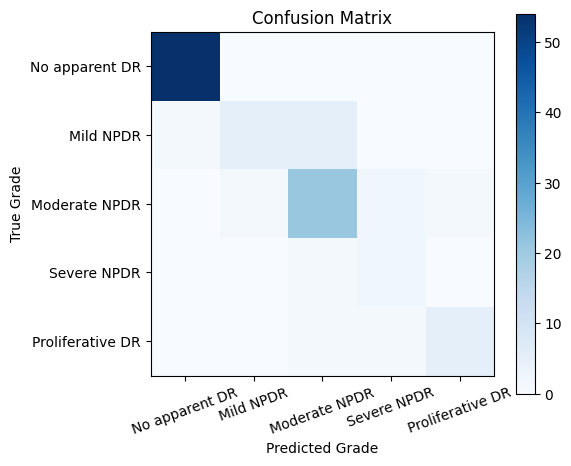

In [208]:
from sklearn.metrics import roc_auc_score, confusion_matrix

model.eval()
all_preds, all_labels, all_conf = [], [], []

for idx in val_data.indices[:100]:
    raw   = aptos[idx]
    image = raw['image'].convert('RGB')
    label = raw['label_code']

    img_tensor = val_transform(image).unsqueeze(0)
    mc         = mc_dropout_predict(model, img_tensor, n_passes=20)

    all_preds.append(mc['grade'])
    all_labels.append(label)
    all_conf.append(mc['confidence'])

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Accuracy
accuracy = (all_preds == all_labels).mean()
print(f'Accuracy:    {accuracy:.4f}')

# Binary: referable (>=2) vs not
pred_ref = (all_preds  >= 2).astype(int)
true_ref = (all_labels >= 2).astype(int)

TP = np.sum((pred_ref == 1) & (true_ref == 1))
TN = np.sum((pred_ref == 0) & (true_ref == 0))
FP = np.sum((pred_ref == 1) & (true_ref == 0))
FN = np.sum((pred_ref == 0) & (true_ref == 1))

sensitivity = TP / (TP + FN + 1e-8)
specificity = TN / (TN + FP + 1e-8)
print(f'Sensitivity: {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')

# AUC
if len(np.unique(true_ref)) > 1:
    all_referable_probs = []

    for idx in val_data.indices[:100]:
        raw        = aptos[idx]
        image      = raw['image'].convert('RGB')
        img_tensor = val_transform(image).unsqueeze(0)
        mc         = mc_dropout_predict(model, img_tensor, n_passes=20)
        ref_prob   = sum(mc['probs_mean'][2:])
        all_referable_probs.append(ref_prob)

    auc = roc_auc_score(true_ref, np.array(all_referable_probs))
    print(f'AUC-ROC:     {auc:.4f}')

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xlabel('Predicted Grade')
plt.ylabel('True Grade')
plt.title('Confusion Matrix')
plt.xticks(range(5), DR_GRADES.values(), rotation=20)
plt.yticks(range(5), DR_GRADES.values())
plt.tight_layout()
plt.show()